# IWAE on Colored MNIST
Importance-Weighted Autoencoder

In [ ]:
from vae_project.imports import *
from vae_project.dataset import *
from vae_project.utils import *
from vae_project.train.hooks import *
from vae_project import TrainerIWAE, get_dataset, IWAE

In [ ]:
train_ds, val_ds = get_dataset("../data"), get_dataset('../data', train=False)

batch_tfms = [ToBatchTransform(tv.transforms.Pad(2)), Colorize('label')]
collate_fn = CollateWithTransforms(batch_tfms)

In [ ]:
bs = 128
train_dl = DataLoader(train_ds, bs, collate_fn=collate_fn)
val_dl = DataLoader(val_ds, bs*2, collate_fn=collate_fn)
xb, yb = next(iter(train_dl))

In [ ]:
K_train = 5  # importance samples during training
K_eval = 50  # tighter bound for evaluation
seed = 42
latent_dim = 16
h_dim = 64
wd = 1e-4
channels = (3, 32, 64, 128)
epochs = 25
lr = 1e-3

random_seed(seed)
collate_fn = CollateWithTransforms(batch_tfms or [])

dl_kwargs = dict(collate_fn=collate_fn, num_workers=6, persistent_workers=True)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, **dl_kwargs)
val_dl = DataLoader(val_ds, batch_size=bs, **dl_kwargs)

recon_dist = 'bce'
model = IWAE(channels, input_size=(32, 32), latent_dim=latent_dim, h_dim=h_dim, recon_dist=recon_dist)

optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
hooks = [MetricsHook(), ProgressBarHook()]

trainer_config = dict(
    K_train=K_train,
    K_eval=K_eval,
    model=model,
    train_dl=train_dl,
    valid_dl=val_dl,
    optim=optimizer,
    epochs=epochs,
    hooks=hooks,
)

trainer = TrainerIWAE(**trainer_config)

In [ ]:
trainer.fit()

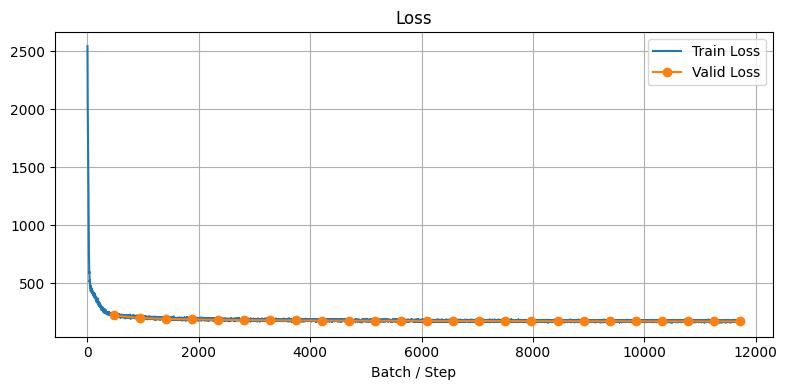

In [ ]:
trainer.get_hook(MetricsHook).plot_loss()

Text(0.5, 1.0, 'Inputs')

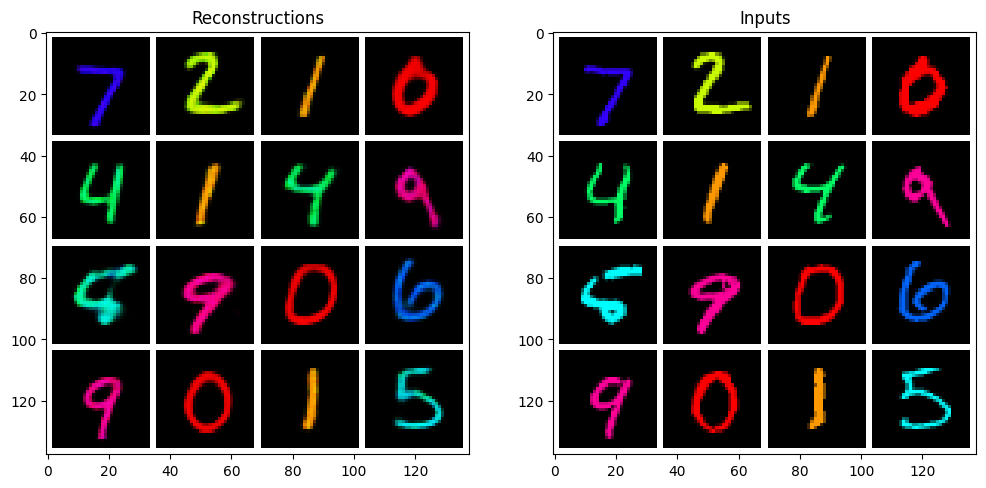

In [ ]:
xb, _ = next(iter(trainer.valid_dl))
x = xb[:16]
recon = trainer.predict(x, training=False)
axes = plt.subplots(ncols=2, figsize=(12,8))[1]
show_imgs(recon[:,0], axes[0])
axes[0].set_title('Reconstructions')
show_imgs(x, axes[1])
axes[1].set_title('Inputs')

### Samples
It seems that model matches prior too good, that gradients are almost zero, so we have to add more noise which makes generations worse

<Axes: title={'center': 'Langevin sampling 10 steps'}>

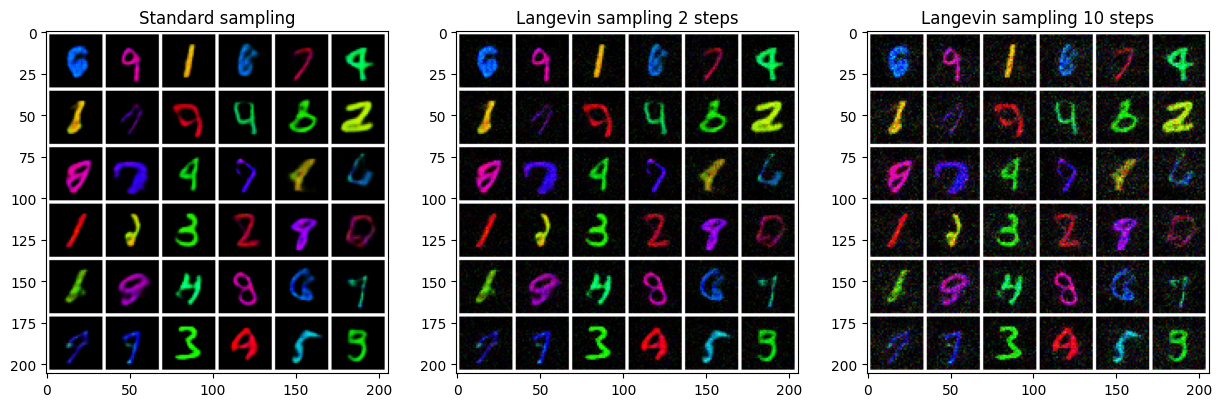

In [ ]:
n_samples = 36
axes = plt.subplots(ncols=3, figsize=(15,8))[1]
random_seed(0)
show_imgs(model.sample(n_samples), axes[0], 'Standard sampling')
random_seed(0)
show_imgs(model.langevin_sample(n=n_samples, eps=0.05, n_steps=2), axes[1], "Langevin sampling 2 steps")
random_seed(0)
show_imgs(model.langevin_sample(n=n_samples,eps=0.05, n_steps=10), axes[2], "Langevin sampling 10 steps")

## Hypothesis test: try to make model ignore the prior more
We add beta scalar to the loss that reduces influence of KL term. Then model will be good at reconstruction, but the difference between prior and posteroir will be higher, so with Langeving dynamics we can move towards more correct posterior

In [ ]:
trainer.hooks.append(BetaSchedulerHook(start=0, end=0.3))

In [ ]:
trainer.fit()

Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/25 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/25 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/25 | Train Loss: 359.2707 | Val Loss: 199.5089


Epoch 2/25 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 24/25 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 24/25 | Train Loss: 150.5635 | Val Loss: 152.0611


Epoch 25/25 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 25/25 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 25/25 | Train Loss: 150.7686 | Val Loss: 152.0662


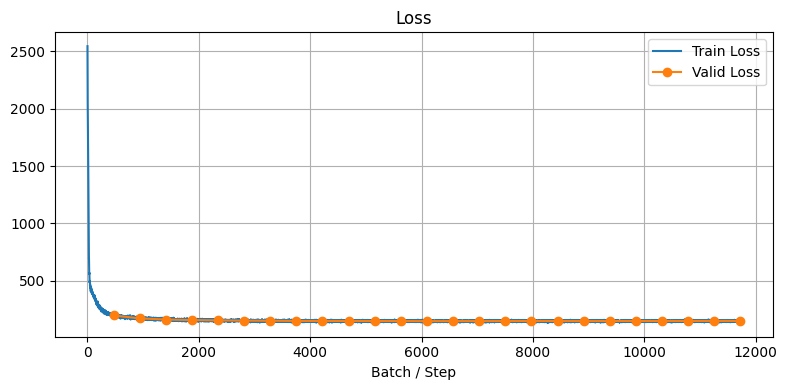

In [ ]:
trainer.get_hook(MetricsHook).plot_loss()

Text(0.5, 1.0, 'Inputs')

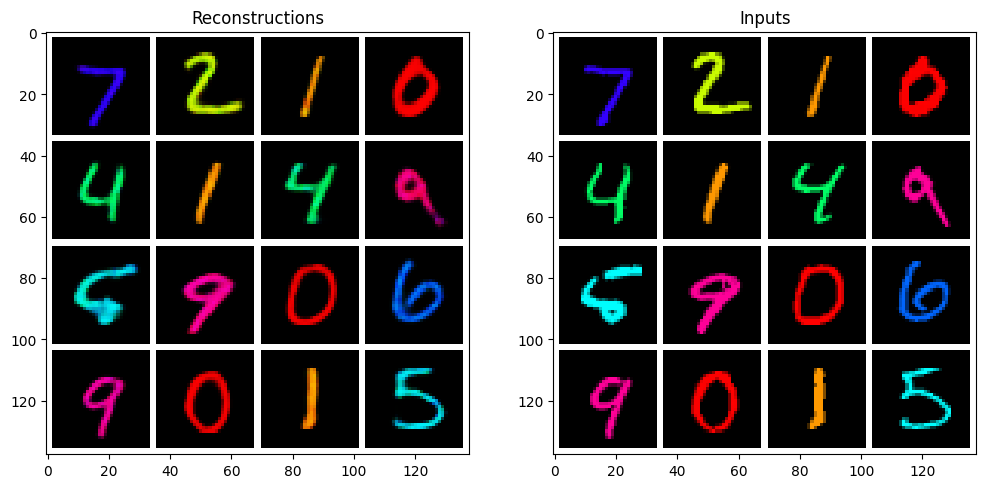

In [ ]:
xb, _ = next(iter(trainer.valid_dl))
x = xb[:16]
recon = trainer.predict(x, training=False)
axes = plt.subplots(ncols=2, figsize=(12,8))[1]
show_imgs(recon[:,0], axes[0])
axes[0].set_title('Reconstructions')
show_imgs(x, axes[1])
axes[1].set_title('Inputs')

Doesn't look like it helped much

<Axes: title={'center': 'Langevin sampling 10 steps'}>

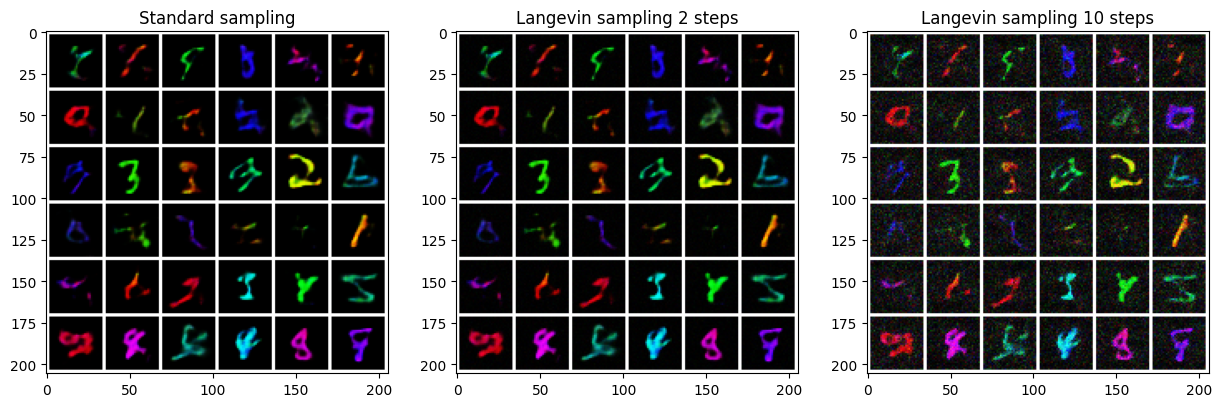

In [ ]:
seed = 1
n_samples, eps = 36, 4e-3
axes = plt.subplots(ncols=3, figsize=(15,8))[1]
random_seed(seed)
show_imgs(model.sample(n_samples), axes[0], 'Standard sampling')
random_seed(seed)
show_imgs(model.langevin_sample(n=n_samples, eps=eps, n_steps=10), axes[1], "Langevin sampling 2 steps")
random_seed(seed)
show_imgs(model.langevin_sample(n=n_samples,eps=eps, n_steps=1_000), axes[2], "Langevin sampling 10 steps")